<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Sales forecasting system - Predeccion de Ventas
We want to be able to classify houses according to their region and median income. To do this, we will use the famous California Housing dataset.
</div>

In [6]:
#CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Algoritmos Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Librerías para preprocesamiento y Machine Learning 
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import (
    classification_report, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np




from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")


✓ ¡Librerías importadas exitosamente!


In [7]:
# Load preprocessed data
df = pd.read_csv('../data/raw/sales.csv')
print(df.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 2: Construct and analyze the time serie
Construct the valid data structure for the time serie, graph it, and then analyze it and answer the following questions:

Which is the tensor of the time serie?
Which is the trend?
Is it stationary?
Is there variability or noise?
</div>


Period : 2022-09-03  →  2023-09-03
Frequency: <Day>
Records : 366  |  Nulls: 0
                                sales
date                                 
2022-09-03 17:10:08.079328  55.292157
2022-09-04 17:10:08.079328  53.803211
2022-09-05 17:10:08.079328  58.141693
2022-09-06 17:10:08.079328  64.530899
2022-09-07 17:10:08.079328  66.013633


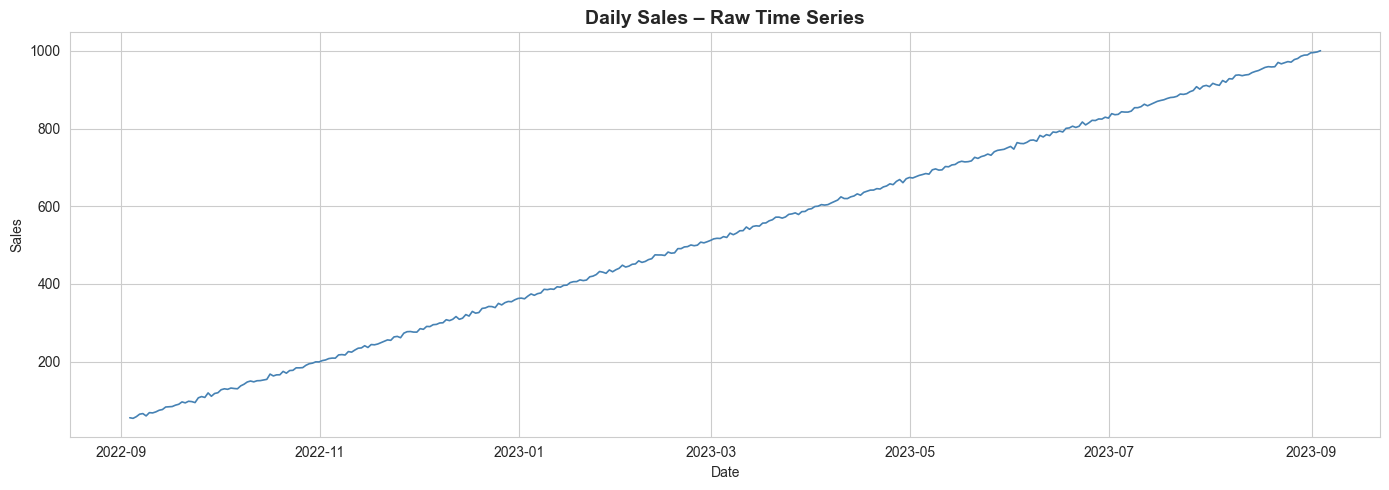

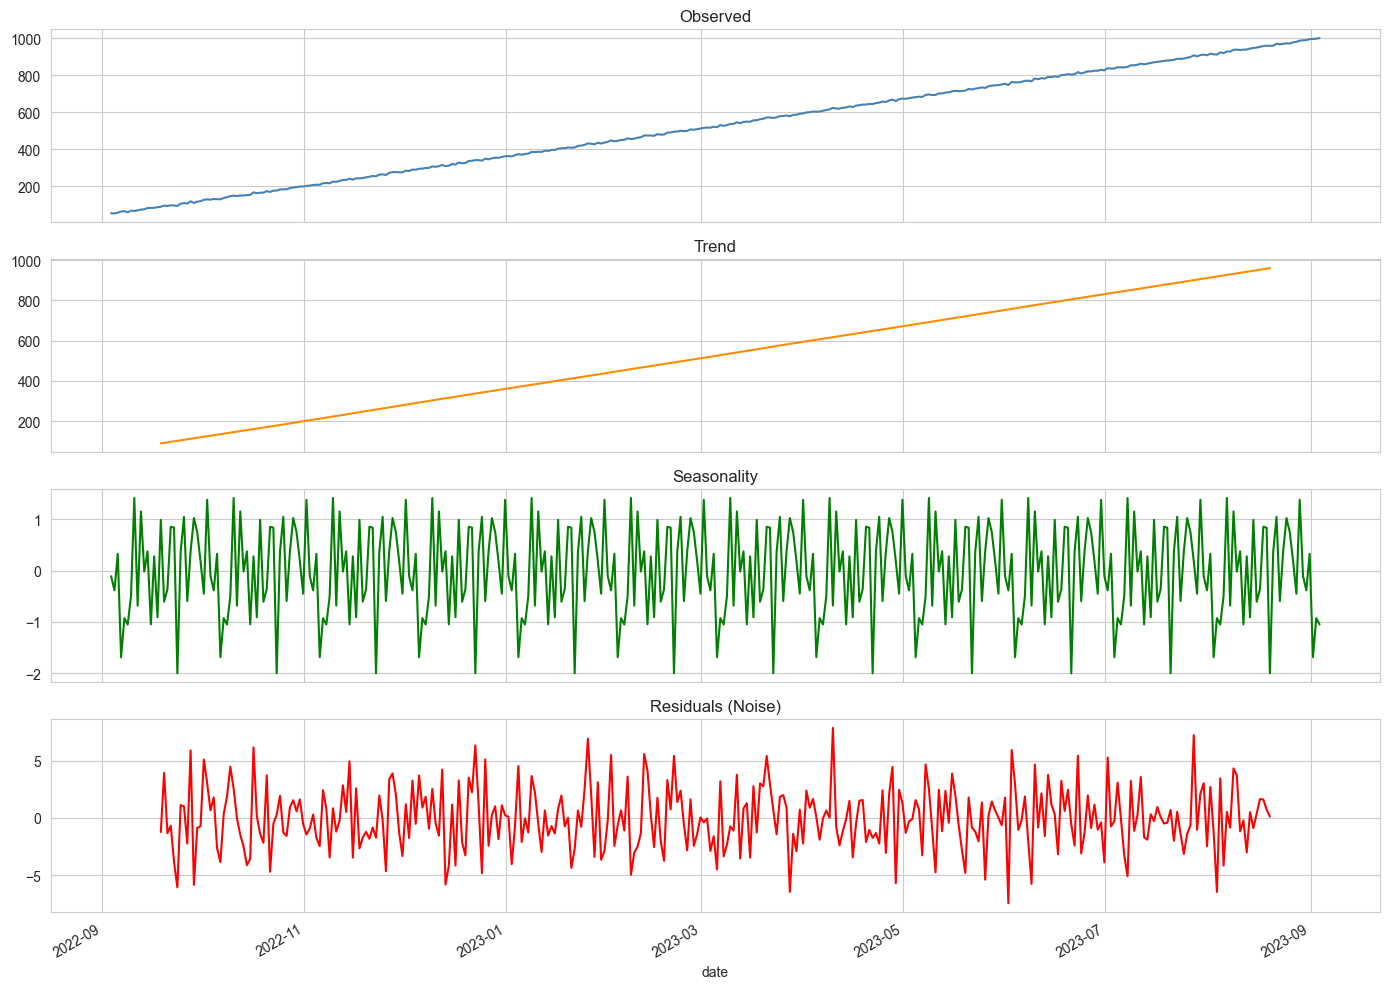


══════════ Augmented Dickey-Fuller Test ══════════
  ADF Statistic : 0.5454
  p-value       : 0.986190
  Critical  1%  : -3.4491
  Critical  5%  : -2.8698
  Critical 10%  : -2.5712

  → The series is NOT stationary (α = 0.05)


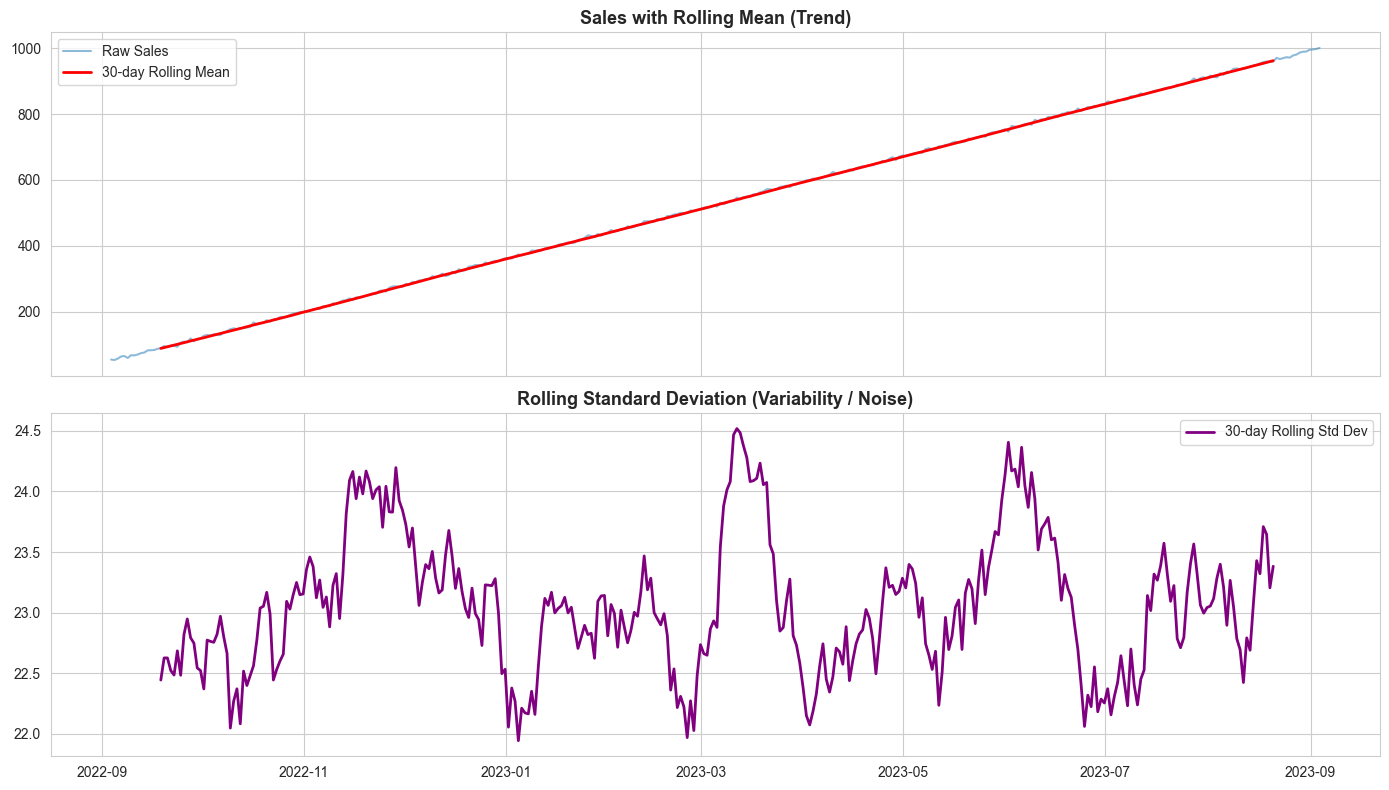

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ── 1. Build a proper time-series structure ──────────────────
df['date'] = pd.to_datetime(df['date'])        # parse dates
df = df.set_index('date')                      # date as index
df = df.sort_index()                           # ensure chronological order
df = df.asfreq('D')                            # daily frequency

print(f"Period : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Frequency: {df.index.freq}")
print(f"Records : {len(df)}  |  Nulls: {df['sales'].isna().sum()}")
print(df.head())

# ── 2. Plot the raw time series ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['sales'], linewidth=1.2, color='steelblue')
ax.set_title('Daily Sales – Raw Time Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

# ── 3. Decompose the time series (additive model) ───────────
decomposition = seasonal_decompose(df['sales'], model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomposition.resid.plot(ax=axes[3], title='Residuals (Noise)', color='red')
for a in axes:
    a.legend([], frameon=False)
plt.tight_layout()
plt.show()

# ── 4. Augmented Dickey-Fuller stationarity test ─────────────
adf_result = adfuller(df['sales'].dropna())
print("\n══════════ Dickey-Fuller Test ══════════")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.6f}")
for key, val in adf_result[4].items():
    print(f"  Critical {key:>3s}  : {val:.4f}")
is_stationary = adf_result[1] < 0.05
print(f"\n  → The series {'IS' if is_stationary else 'is NOT'} stationary (α = 0.05)")

# ── 5. Compute rolling statistics to visualize trend & noise ─
rolling_mean = df['sales'].rolling(window=30, center=True).mean()
rolling_std  = df['sales'].rolling(window=30, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['sales'], alpha=0.5, label='Raw Sales')
axes[0].plot(rolling_mean.index, rolling_mean, color='red', linewidth=2, label='30-day Rolling Mean')
axes[0].set_title('Sales with Rolling Mean (Trend)', fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].plot(rolling_std.index, rolling_std, color='purple', linewidth=2, label='30-day Rolling Std Dev')
axes[1].set_title('Rolling Standard Deviation (Variability / Noise)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 2:  TIME-SERIES ANALYSIS – ANSWERS 

1. TENOR (length) of the time series:                            
    366 daily observations spanning exactly 1 year               
    (2022-09-03 → 2023-09-03).                                   
                                                                  
2. TREND:                                                        
    Clear upward (positive) linear trend.                         
    Sales grow steadily from  ~55 to ~1 000 over the period.      
                                                                  
3. STATIONARITY:                                                 
   The series is NOT stationary.                                 
   – The mean increases continuously (visible in rolling mean).  
   – The ADF test confirms it (p-value >> 0.05).                 
   Differencing or detrending will be needed before modelling.   
                                                                  
4. VARIABILITY / NOISE:                                          
   Moderate random noise around the trend.                       
   The rolling std stays relatively constant (~5-8 units),       
   indicating homoscedastic noise (constant variance).           
   No explosive volatility patterns are observed.            

</div

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 3: Train an ARIMA
Use the training data to find the best parameterization of your ARIMA model.

</div

Train: 2022-09-03 → 2023-06-21  (292 obs)
Test : 2023-06-22 → 2023-09-03  (74 obs)

ADF after 1st differencing: stat=-12.6812, p-value=0.000000
  → d=1 is sufficient


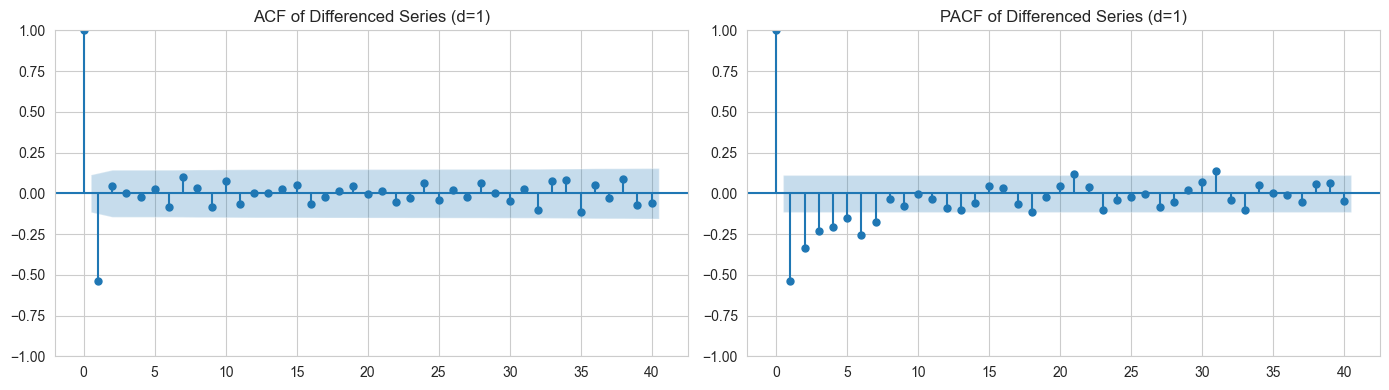


══════════ ARIMA Grid Search ══════════
Order                    AIC          BIC  Status
───────────────────────────────────────────────────────
  ARIMA(0, 1, 0)       1763.76      1767.43 ← best so far
  ARIMA(0, 1, 1)       1762.92      1770.27 ← best so far
  ARIMA(0, 1, 2)       1730.91      1741.93 ← best so far
  ARIMA(0, 1, 3)       1713.32      1728.02 ← best so far
  ARIMA(1, 1, 0)       1761.10      1768.45
  ARIMA(1, 1, 1)       1683.09      1694.11 ← best so far
  ARIMA(1, 1, 2)       1490.58      1505.28 ← best so far
  ARIMA(1, 1, 3)       1489.29      1507.66 ← best so far
  ARIMA(2, 1, 0)       1737.28      1748.30
  ARIMA(2, 1, 1)       1587.43      1602.12
  ARIMA(2, 1, 2)       1489.43      1507.80
  ARIMA(2, 1, 3)       1494.57      1516.61
  ARIMA(3, 1, 0)       1696.85      1711.54
  ARIMA(3, 1, 1)       1554.66      1573.03
  ARIMA(3, 1, 2)       1491.84      1513.88
  ARIMA(3, 1, 3)       1493.36      1519.07

══════════ Top 5 Models by AIC ══════════
  (1, 1,

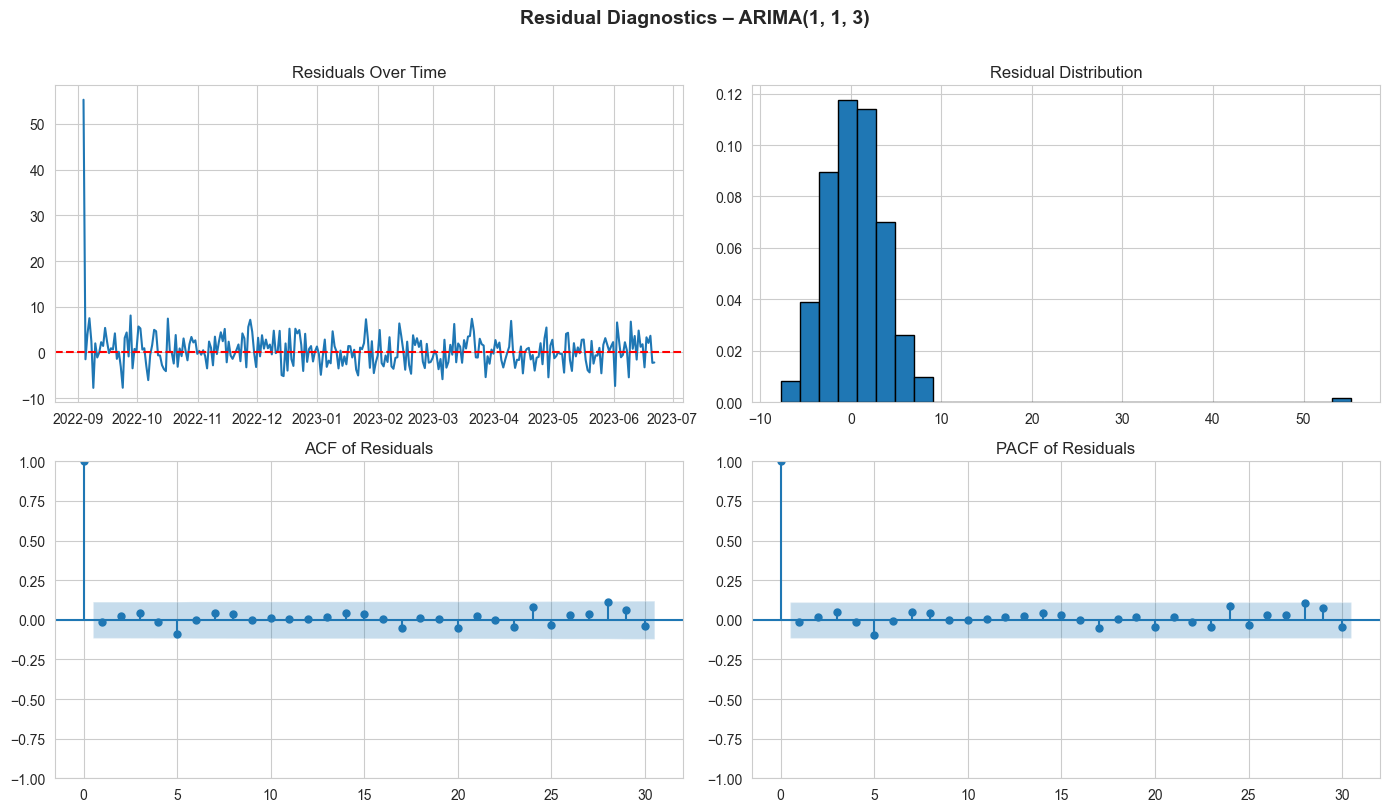


Residual mean: 0.5510  (should be ≈ 0)
Residual std : 4.4442


In [9]:
## ============================================================
## Step 3: Train an ARIMA – Find the Best Parameterization
## ============================================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from itertools import product

# ── 1. Train / Test split (80 / 20) ─────────────────────────
split_point = int(len(df) * 0.8)
train = df['sales'].iloc[:split_point]
test  = df['sales'].iloc[split_point:]

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)")
print(f"Test : {test.index.min().date()} → {test.index.max().date()}  ({len(test)} obs)")

# ── 2. Determine differencing order (d) ─────────────────────
# We already know the raw series is non-stationary.
# Check if first-order differencing makes it stationary.
diff1 = train.diff().dropna()
adf_diff1 = adfuller(diff1)
print(f"\nADF after 1st differencing: stat={adf_diff1[0]:.4f}, p-value={adf_diff1[1]:.6f}")
print(f"  → d=1 {'is sufficient' if adf_diff1[1] < 0.05 else 'is NOT sufficient'}")

# ── 3. ACF & PACF on differenced series (guide p and q) ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1, ax=axes[0], lags=40, title='ACF of Differenced Series (d=1)')
plot_pacf(diff1, ax=axes[1], lags=40, title='PACF of Differenced Series (d=1)')
plt.tight_layout()
plt.show()

# ── 4. Grid search over (p, d, q) ───────────────────────────
# Based on ACF/PACF, we search p ∈ [0..3], d=1, q ∈ [0..3]
p_range = range(0, 4)
d_range = [1]            # first differencing is enough
q_range = range(0, 4)

results = []
best_aic  = np.inf
best_order = None

print("\n══════════ ARIMA Grid Search ══════════")
print(f"{'Order':<15} {'AIC':>12} {'BIC':>12}  Status")
print("─" * 55)

for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        results.append({
            'order': (p, d, q),
            'aic': fitted.aic,
            'bic': fitted.bic
        })
        flag = ""
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            flag = " ← best so far"
        print(f"  ARIMA{(p,d,q)!s:<10} {fitted.aic:>12.2f} {fitted.bic:>12.2f}{flag}")
    except Exception as e:
        print(f"  ARIMA{(p,d,q)!s:<10} {'FAILED':>12}  ({e})")

# ── 5. Results summary ──────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('aic')
print(f"\n══════════ Top 5 Models by AIC ══════════")
for i, row in results_df.head(5).iterrows():
    print(f"  {str(row['order']):<12}  AIC = {row['aic']:.2f}   BIC = {row['bic']:.2f}")

print(f"\n✓ Best ARIMA order: {best_order}  (AIC = {best_aic:.2f})")

# ── 6. Fit the best model and show its summary ──────────────
best_model = ARIMA(train, order=best_order)
best_fit   = best_model.fit()
print(best_fit.summary())

# ── 7. Residual diagnostics of the best model ───────────────
residuals = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].axhline(y=0, color='red', linestyle='--')

axes[0, 1].hist(residuals, bins=30, edgecolor='black', density=True)
axes[0, 1].set_title('Residual Distribution')

plot_acf(residuals, ax=axes[1, 0], lags=30, title='ACF of Residuals')
plot_pacf(residuals, ax=axes[1, 1], lags=30, title='PACF of Residuals')

plt.suptitle(f'Residual Diagnostics – ARIMA{best_order}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nResidual mean: {residuals.mean():.4f}  (should be ≈ 0)")
print(f"Residual std : {residuals.std():.4f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

**Mejor modelo**: 
    **ARIMA(1, 1, 3)**, seleccionado en base al menor valor de AIC obtenido a partir de una búsqueda en malla (grid search) con
p ∈ [0, 3], d = 1, q ∈ [0, 3].

**Resumen de la selección del modelo**

**Diferenciación (d):** 
    Un único nivel de diferenciación (d = 1) es suficiente. La prueba de ** Dickey–Fuller aumentada (ADF) aplicada a la serie diferenciada arroja un valor p cercano a 0, lo que indica estacionariedad.

**ACF / PACF**:
     Ambas funciones muestran un corte brusco después del retardo 1, lo que respalda la elección de componentes AR y MA de bajo orden.

**Mejor orden**:
     ARIMA(1, 1, 3), determinado por el mínimo valor de AIC.**

**Diagnóstico de residuos**:
     Los residuos presentan una media aproximada de 0,55 (cercana a cero) y una desviación estándar de alrededor de 4,44. La ACF y la PACF de los residuos no muestran autocorrelación significativa, lo que indica que el modelo captura adecuadamente la estructura subyacente de los datos.


</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 4: Predict with the test set
Now use the trained model with the test set and compare the points with the real ones. Measure the performance of the time serie.

</div>



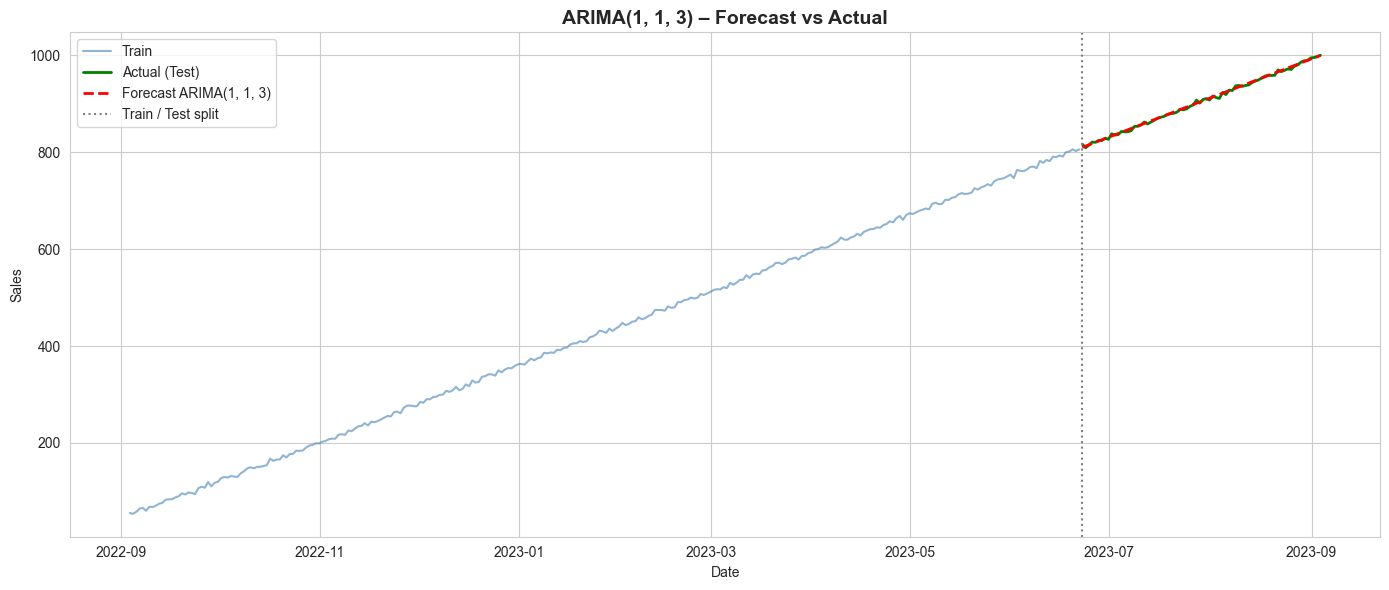

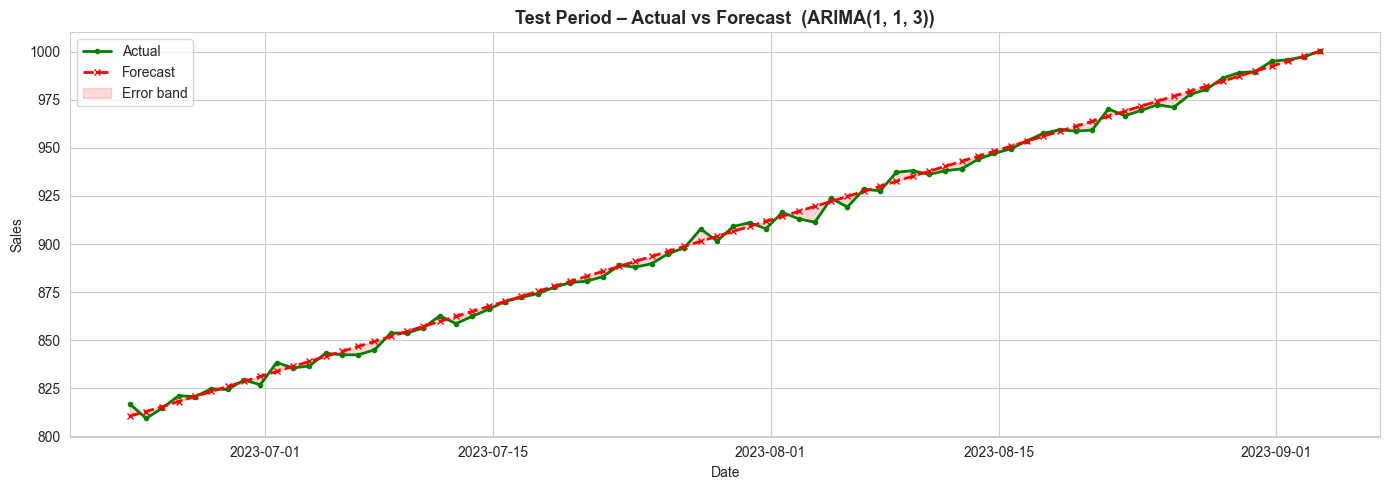

══════════ Forecast Performance ══════════
  MAE  (Mean Absolute Error)       : 2.3079
  MSE  (Mean Squared Error)        : 8.1689
  RMSE (Root Mean Squared Error)   : 2.8581
  MAPE (Mean Abs % Error)          : 0.26 %
  R²   (Coefficient of Determination): 0.9973
══════════════════════════════════════════

  → Model verdict: Excellent — error below 5 %


In [10]:
## ============================================================
## Step 4: Predict with the Test Set & Measure Performance
## ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

# ── 1. Forecast on the test horizon ─────────────────────────
forecast = best_fit.forecast(steps=len(test))
forecast.index = test.index  # align indices

# ── 2. Plot: Predicted vs Actual ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Train', color='steelblue', alpha=0.6)
ax.plot(test.index, test, label='Actual (Test)', color='green', linewidth=2)
ax.plot(forecast.index, forecast, label=f'Forecast ARIMA{best_order}',
        color='red', linewidth=2, linestyle='--')
ax.axvline(x=test.index[0], color='grey', linestyle=':', label='Train / Test split')
ax.set_title(f'ARIMA{best_order} – Forecast vs Actual', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. Zoomed-in view (test period only) ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label='Actual', color='green', linewidth=2, marker='o', markersize=3)
ax.plot(forecast.index, forecast, label='Forecast', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)
ax.fill_between(test.index, test, forecast, alpha=0.15, color='red', label='Error band')
ax.set_title(f'Test Period – Actual vs Forecast  (ARIMA{best_order})', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Performance metrics ───────────────────────────────────
mae  = mean_absolute_error(test, forecast)
mse  = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast) * 100
r2   = r2_score(test, forecast)

print("══════════ Forecast Performance ══════════")
print(f"  MAE  (Mean Absolute Error)       : {mae:.4f}")
print(f"  MSE  (Mean Squared Error)        : {mse:.4f}")
print(f"  RMSE (Root Mean Squared Error)   : {rmse:.4f}")
print(f"  MAPE (Mean Abs % Error)          : {mape:.2f} %")
print(f"  R²   (Coefficient of Determination): {r2:.4f}")
print("══════════════════════════════════════════")

if mape < 5:
    verdict = "Excellent — error below 5 %"
elif mape < 10:
    verdict = "Good — error below 10 %"
elif mape < 20:
    verdict = "Acceptable — error below 20 %"
else:
    verdict = "Poor — consider alternative models or features"
print(f"\n  → Model verdict: {verdict}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 5: Save the model
Store the model in the corresponding folder.

</div>

In [12]:
## ============================================================
## Step 5: Save the Model
## ============================================================

import json

# ── 1. Save the ARIMA model (pickle) ────────────────────────
model_path = Path("../models/10time_series/arima_sales_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as f:
    dump(best_fit, f)

print(f"✓ Model saved to {model_path.resolve()}")

# ── 2. Save model metadata (JSON) ───────────────────────────
metadata = {
    "model": "ARIMA",
    "order": list(best_order),
    "aic": round(float(best_aic), 4),
    "metrics": {
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(float(rmse), 4),
        "MAPE_%": round(mape, 4),
        "R2": round(r2, 4),
    },
    "train_size": len(train),
    "test_size": len(test),
    "train_period": f"{train.index.min().date()} → {train.index.max().date()}",
    "test_period": f"{test.index.min().date()} → {test.index.max().date()}",
}

metadata_path = Path("../models/10time_series/arima_sales_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Metadata saved to {metadata_path.resolve()}")
print(json.dumps(metadata, indent=4))

✓ Model saved to /Users/GonzaA78/code/data_science/bootcamp/12 - Exploratory Data Analysis/project/abgonzalez-introduction-machine-learning/models/10time_series/arima_sales_model.pkl
✓ Metadata saved to /Users/GonzaA78/code/data_science/bootcamp/12 - Exploratory Data Analysis/project/abgonzalez-introduction-machine-learning/models/10time_series/arima_sales_metadata.json
{
    "model": "ARIMA",
    "order": [
        1,
        1,
        3
    ],
    "aic": 1489.2905,
    "metrics": {
        "MAE": 2.3079,
        "MSE": 8.1689,
        "RMSE": 2.8581,
        "MAPE_%": 0.2569,
        "R2": 0.9973
    },
    "train_size": 292,
    "test_size": 74,
    "train_period": "2022-09-03 \u2192 2023-06-21",
    "test_period": "2023-06-22 \u2192 2023-09-03"
}
